#  Аналіз ринку ноутбуків на базі 3 магазинів (Foxtrot. Telemart. Brain)

# Підготовка даних

In [942]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

## Завантажуємо дані

In [943]:
foxtrot = pd.read_csv(r"D:\projects\Mega-laptop-parser\data\foxtrot_data.csv")
brain = pd.read_csv(r"D:\projects\Mega-laptop-parser\data\brain_data.csv")
telemart = pd.read_csv(r"D:\projects\Mega-laptop-parser\data\telemart_data.csv")
cpu_rating = pd.read_csv(r"D:\projects\Mega-laptop-parser\data\technical_city_cpu.csv")
gpu_rating = pd.read_csv(r"D:\projects\Mega-laptop-parser\data\technical_city_gpu.csv")

In [944]:
foxtrot = pd.DataFrame(foxtrot)
brain = pd.DataFrame(brain)
telemart = pd.DataFrame(telemart)
cpurating = pd.DataFrame(cpu_rating)
gpurating = pd.DataFrame(gpu_rating)

## Чистка даних

#### Foxtrot

In [945]:
foxtrot["shop"] ="foxtrot"
foxtrot["product_code"] = foxtrot["product_code"].astype(int)
foxtrot.info()

<class 'pandas.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   full_name     840 non-null    str    
 1   price         840 non-null    float64
 2   product_code  840 non-null    int64  
 3   shop          840 non-null    str    
 4   product_url   840 non-null    str    
 5   cpu           840 non-null    str    
 6   gpu           596 non-null    str    
 7   other         840 non-null    str    
dtypes: float64(1), int64(1), str(6)
memory usage: 52.6 KB


In [946]:
def full_name(name: str, l: list):
    if not isinstance(name, str):
        return name
    
    name = name.strip()
    pattern = rf"\b{re.escape(name)}\b"

    # Шукаємо повнішу назву у рейтингу
    for full_name in l:
        if isinstance(full_name, str) and re.search(pattern.lower(), full_name.lower()):
            return full_name
    
    return name

In [947]:
cpulist = cpu_rating['full_name'].tolist()
foxtrot['cpu'] = foxtrot['cpu'].apply(lambda x: full_name(x, cpulist))
foxtrot.info()

<class 'pandas.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   full_name     840 non-null    str    
 1   price         840 non-null    float64
 2   product_code  840 non-null    int64  
 3   shop          840 non-null    str    
 4   product_url   840 non-null    str    
 5   cpu           840 non-null    str    
 6   gpu           596 non-null    str    
 7   other         840 non-null    str    
dtypes: float64(1), int64(1), str(6)
memory usage: 52.6 KB


#### Brain

In [948]:
brain.info()

<class 'pandas.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   full_name     480 non-null    str    
 1   price         480 non-null    float64
 2   product_code  480 non-null    str    
 3   shop          480 non-null    str    
 4   product_url   480 non-null    str    
 5   cpu           480 non-null    str    
 6   gpu           480 non-null    str    
 7   other         480 non-null    str    
dtypes: float64(1), str(7)
memory usage: 30.1 KB


#### Telemart

In [949]:
telemart['shop'] = 'telemart'
telemart['product_code'] = telemart['product_code'].astype(int)
telemart.info()

<class 'pandas.DataFrame'>
RangeIndex: 741 entries, 0 to 740
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   full_name     741 non-null    str    
 1   price         741 non-null    float64
 2   product_code  741 non-null    int64  
 3   shop          741 non-null    str    
 4   product_url   741 non-null    str    
 5   cpu           741 non-null    str    
 6   gpu           741 non-null    str    
 7   other         741 non-null    str    
dtypes: float64(1), int64(1), str(6)
memory usage: 46.4 KB


#### CPU & GPU

In [950]:
cpu_rating = cpu_rating.drop('name', axis=1)
gpu_rating = gpu_rating.drop('name', axis=1)

In [951]:
cpu_rating = cpu_rating[cpu_rating['full_name'].notna()]
gpu_rating = gpu_rating[gpu_rating['full_name'].notna()]

In [952]:
cpu_rating.info()

<class 'pandas.DataFrame'>
Index: 3539 entries, 0 to 3542
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   rate         3539 non-null   int64  
 1   full_name    3539 non-null   str    
 2   device_type  3539 non-null   str    
 3   performance  3539 non-null   float64
 4   year         3539 non-null   int64  
 5   tdp          3530 non-null   float64
 6   cores        3539 non-null   int64  
 7   threads      3539 non-null   int64  
dtypes: float64(2), int64(4), str(2)
memory usage: 248.8 KB


### Створення універсального датафрейму

#### Універсальний датафрейм

In [953]:
all_shop = pd.concat([brain, telemart, foxtrot])
# all_shop = all_shop.fillna(0)
all_shop.info()

<class 'pandas.DataFrame'>
Index: 2061 entries, 0 to 839
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   full_name     2061 non-null   str    
 1   price         2061 non-null   float64
 2   product_code  2061 non-null   object 
 3   shop          2061 non-null   str    
 4   product_url   2061 non-null   str    
 5   cpu           2061 non-null   str    
 6   gpu           1817 non-null   str    
 7   other         2061 non-null   str    
dtypes: float64(1), object(1), str(6)
memory usage: 144.9+ KB


#### Чистка та стандартизація

In [954]:
def clean_cpu(name: str):
    if not isinstance(name, str):
        return name
    if 'Intel Core Ultra' in name:
        return name.replace('-', " ")
    return name


all_shop['cpu'] = all_shop['cpu'].str.replace(r"\s\(.*?\)", "", regex=True).str.strip().apply(lambda x: clean_cpu(x))

In [955]:
def clean_gpu(name):
    if not isinstance(name, str):
        return name
    if "AMD" in name:
        name = re.sub(r"\bGraphics\b", "", name).strip()
    return re.sub(r"\s+", " ", name)

gpulist = gpu_rating['full_name'].tolist()
all_shop['gpu'] = all_shop['gpu'].fillna("").apply(lambda x: full_name(x, gpulist)).apply(lambda x: clean_gpu(x))

In [956]:
all_shop['cpu'].drop_duplicates().sort_values().to_csv("data/cpu_uniqe.csv", index=False, header=False)
all_shop['gpu'].drop_duplicates().sort_values().to_csv("data/gpu_uniqe.csv", index=False, header=False)
cpu_rating['full_name'].drop_duplicates().sort_values().to_csv("data/tcpu.csv", index=False, header=False)
gpu_rating['full_name'].drop_duplicates().sort_values().to_csv("data/tgpu.csv", index=False, header=False)

In [957]:
laptop_rating = pd.merge(left=all_shop, right=cpu_rating, how="left", left_on="cpu", right_on="full_name", validate="m:1")
# laptop_rating.head(3)

In [958]:
laptop_rating = pd.merge(left=laptop_rating, right=gpu_rating, how="left", left_on="gpu", right_on="full_name", suffixes=['_cpu', '_gpu'], validate="m:1")
# laptop_rating.head(3)

In [959]:
laptop_rating = laptop_rating.rename(columns={
    'full_name':'gpu_name',
    'full_name_y':'cpu_name',
    'full_name_x': 'laptop_name'}
    )
laptop_rating[['rate_cpu', 'rate_gpu', 'cores', 'threads', 'year_cpu', 'year_gpu']] = laptop_rating[['rate_cpu', 'rate_gpu', 'cores', 'threads', 'year_cpu', 'year_gpu']]
laptop_rating = laptop_rating.drop_duplicates()
laptop_rating.info()

<class 'pandas.DataFrame'>
Index: 2030 entries, 0 to 2060
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   laptop_name      2030 non-null   str    
 1   price            2030 non-null   float64
 2   product_code     2030 non-null   object 
 3   shop             2030 non-null   str    
 4   product_url      2030 non-null   str    
 5   cpu              2030 non-null   str    
 6   gpu              2030 non-null   str    
 7   other            2030 non-null   str    
 8   rate_cpu         1899 non-null   float64
 9   cpu_name         1899 non-null   str    
 10  device_type_cpu  1899 non-null   str    
 11  performance_cpu  1899 non-null   float64
 12  year_cpu         1899 non-null   float64
 13  tdp_cpu          1899 non-null   float64
 14  cores            1899 non-null   float64
 15  threads          1899 non-null   float64
 16  rate_gpu         1791 non-null   float64
 17  gpu_name         1791 non-null

### Функція для отримання додактової характеристики

In [960]:
import ast

def get_spec(string: str, key: str) -> str | None:
    try:
        d: dict = ast.literal_eval(string)
        return d.get(key)
    except:
        return None

# Аналіз даних

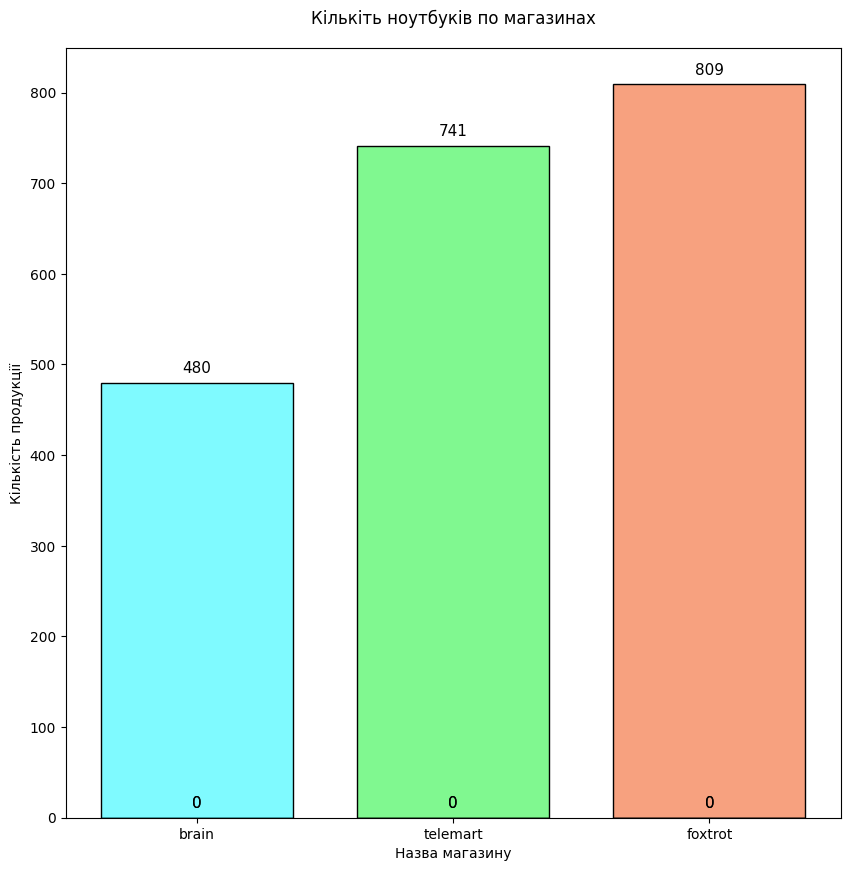

In [961]:
palette = ["#01F7FF", "#03F323", "#F14501"]


plt.figure(figsize=[10, 10])
ax = sns.histplot(
    x='shop', 
    data=laptop_rating, 
    hue='shop',
    shrink=0.75,
    palette=palette,
    edgecolor='black',
    legend=False, 
    cbar=True
)
for container in ax.containers:
    ax.bar_label(container, fontsize=11, padding=5, 
                 label_type='edge', fmt='%d')
plt.title("Кількіть ноутбуків по магазинах", y=1.02)
plt.xlabel("Назва магазину")
plt.ylabel("Кількість продукції")
plt.show()

In [962]:
laptop_rating[laptop_rating['shop']=='brain']['rate_cpu'].sort_values(ascending=False).head()

68     2055.0
89     2055.0
339    1444.0
338    1444.0
297    1444.0
Name: rate_cpu, dtype: float64

In [966]:
laptop_rating["avg_perf_score"] = (laptop_rating['rate_cpu'] + laptop_rating['rate_gpu']) // 2
laptop_rating.sort_values(by=['avg_perf_score', 'price'])
laptop_rating[['cpu', 'cpu_name', "rate_cpu"]].sample(10)
# 'gpu', 'gpu_name', 'rate_gpu'

,cpu,cpu_name,rate_cpu
344,Intel Core Ultra 7 255H,Intel Core Ultra 7 255H,434.0
1943,Intel Core 3 100U,Intel Core 3 100U,1189.0
167,Intel Core i9 13900HX,NaN,NaN
830,AMD Ryzen 5 7520U,AMD Ryzen 5 7520U,1419.0
883,AMD Ryzen 3 7335U,AMD Ryzen 3 7335U,1206.0
1381,Intel Core Ultra 7 258V,Intel Core Ultra 7 258V,859.0
1389,Intel Core Ultra 9 275HX,Intel Core Ultra 9 275HX,171.0
1714,AMD Ryzen 5 PRO 8645HS,AMD Ryzen 5 PRO 8645HS,663.0
332,Intel Core Ultra 7 255H,Intel Core Ultra 7 255H,434.0
1497,Intel Core i5-1334U,Intel Core i5-1334U,1161.0


In [ ]:
# cpu_na = laptop_rating[laptop_rating['rate_gpu'].isna()]
# cpu_na[['gpu']].drop_duplicates()

,gpu
2,AMD Radeon (Ryzen 7000)
9,Intel Iris Xe Graphics eligible
15,UHD Graphics 13th Gen
29,Apple A18 Pro Graphics (5-core GPU)
47,Apple M5 Graphics (10 ядер)
77,Apple M5 Pro Graphics (16-core GPU)
117,M5 Max Graphics (32-core GPU)
159,Apple M5 Pro Graphics (20-core GPU)
169,NVIDIA RTX PRO 1000
454,Intel Arc 140V
